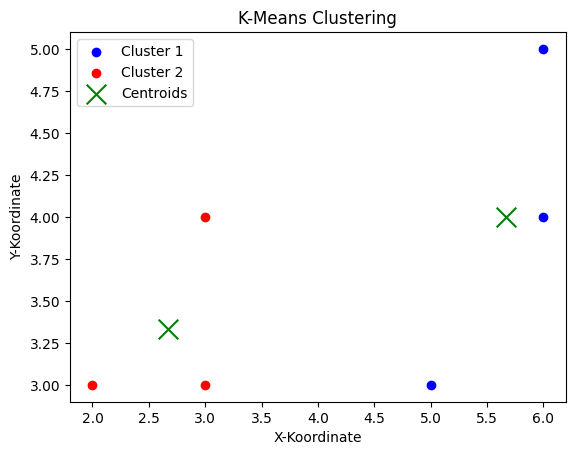

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Datensatz
data = np.array([[2, 3], [3, 3], [3, 4], [5, 3], [6, 4], [6, 5]])

# Anzahl der Cluster (k) festlegen
k = 2

# K-Means-Modell erstellen
kmeans = KMeans(n_clusters=k)

# Modell auf den Datensatz anwenden
kmeans.fit(data)

# Centroids und Cluster-Zuordnung abrufen
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

# Punkte in den Clustern gruppieren
cluster1 = data[labels == 0]
cluster2 = data[labels == 1]

# Visualisierung der Cluster und Centroids
plt.scatter(cluster1[:, 0], cluster1[:, 1], c='blue', label='Cluster 1')
plt.scatter(cluster2[:, 0], cluster2[:, 1], c='red', label='Cluster 2')
plt.scatter(centroids[:, 0], centroids[:, 1], c='green', marker='x', s=200, label='Centroids')
plt.xlabel('X-Koordinate')
plt.ylabel('Y-Koordinate')
plt.legend()
plt.title('K-Means Clustering')
plt.show()


In [2]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
X = np.array([[1, 2], [1, 4], [1, 0],
              [4, 2], [4, 4], [4, 0]])
clustering = AgglomerativeClustering().fit(X)
clustering
clustering.labels_

array([1, 1, 1, 0, 0, 0])

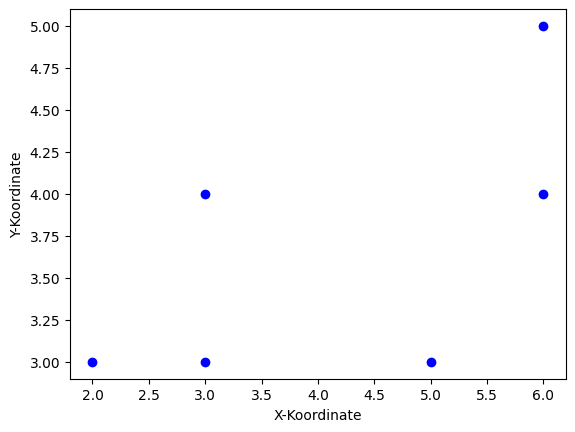

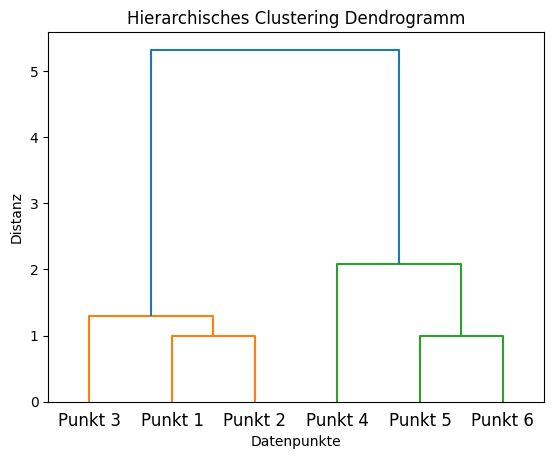

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# Erzeugen von Beispieldatenpunkten
data = np.array([[2, 3], [3, 3], [3, 4], [5, 3], [6, 4], [6, 5]])

# Berechnung der hierarchischen Cluster
distance_matrix = pdist(data)  # Berechnung der Distanzmatrix
linkage_matrix = linkage(distance_matrix, method='ward')  # Verknüpfung der Cluster mit der Ward-Methode

# Erzeugen eines Scatter-Plots der Datenpunkte
plt.figure()
plt.scatter(data[:,0], data[:,1], c='blue', label='Datenpunkte')

plt.xlabel('X-Koordinate')
plt.ylabel('Y-Koordinate')

# Anzeigen des Plots
plt.show()

# Erstellung eines Dendrogramms zur Visualisierung der Hierarchie
dendrogram(linkage_matrix, labels=[f'Punkt {i+1}' for i in range(len(data))])
plt.title('Hierarchisches Clustering Dendrogramm')
plt.xlabel('Datenpunkte')
plt.ylabel('Distanz')
plt.show()


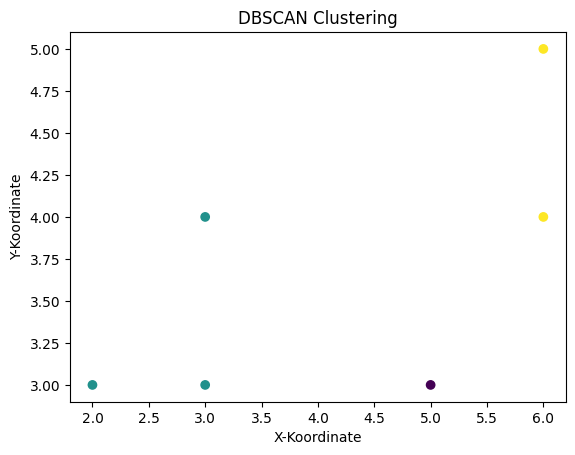

[ 0  0  0 -1  1  1]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Erzeugen von Beispieldatenpunkten
data = np.array([[2, 3], [3, 3], [3, 4], [5, 3], [6, 4], [6, 5]])

# Erstellung des DBSCAN-Modells
dbscan = DBSCAN(eps=1, min_samples=2)  # Parameter eps und min_samples anpassen

# Anpassen des Modells an die Daten
dbscan.fit(data)

# Extrahieren der zugehörigen Clusterlabels
cluster_labels = dbscan.labels_

# Visualisierung der Datenpunkte und Cluster
plt.scatter(data[:, 0], data[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X-Koordinate')
plt.ylabel('Y-Koordinate')
plt.title('DBSCAN Clustering')

plt.show()

print(dbscan.labels_)

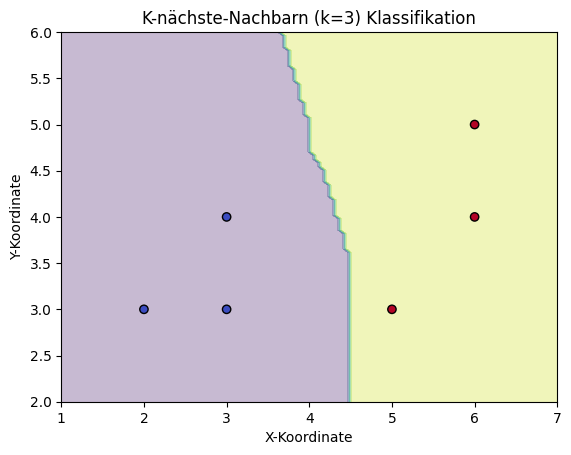

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Beispieldaten aus dem Notebook verwenden
data = np.array([[2, 3], [3, 3], [3, 4], [5, 3], [6, 4], [6, 5]])
labels = np.array([0, 0, 0, 1, 1, 1])  # Annahme: Zwei Klassen für k-NN

# Erstelle das k-NN-Modell mit k=3
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(data, labels)

# Erstelle ein Gitter für die Entscheidungsgrenzen
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Vorhersagen für jedes Gitterpunkt
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualisierung
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(data[:, 0], data[:, 1], c=labels, edgecolors='k', cmap='coolwarm')
plt.xlabel("X-Koordinate")
plt.ylabel("Y-Koordinate")
plt.title(f"K-nächste-Nachbarn (k={k}) Klassifikation")
plt.show()

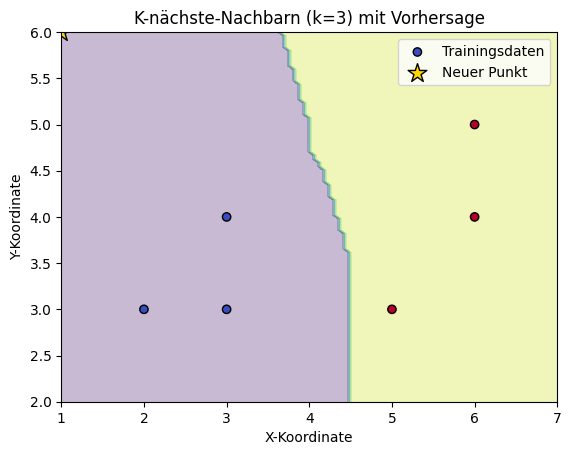

array([0])

In [7]:
# Neuer Punkt für die Vorhersage
new_point = np.array([[1, 6]])

# Vorhersage mit k-NN
predicted_label = knn.predict(new_point)

# Visualisierung mit neuem Punkt
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(data[:, 0], data[:, 1], c=labels, edgecolors='k', cmap='coolwarm', label="Trainingsdaten")
plt.scatter(new_point[:, 0], new_point[:, 1], c='gold', edgecolors='black', marker='*', s=200, label="Neuer Punkt")
plt.xlabel("X-Koordinate")
plt.ylabel("Y-Koordinate")
plt.title(f"K-nächste-Nachbarn (k={k}) mit Vorhersage")
plt.legend()
plt.show()

# Zeige die Vorhersage an
predicted_label
